In [1]:
import torchaudio
import matplotlib.pyplot as plt
import soundfile as sf
import torch
from wavenet.data import DATA_DIR, WAV_DIR
%matplotlib inline

ds = torchaudio.datasets.LJSPEECH(root = DATA_DIR)

In [2]:
w, sr = sf.read(WAV_DIR / "LJ001-0001.wav", dtype="float32")
w = torch.from_numpy(w)

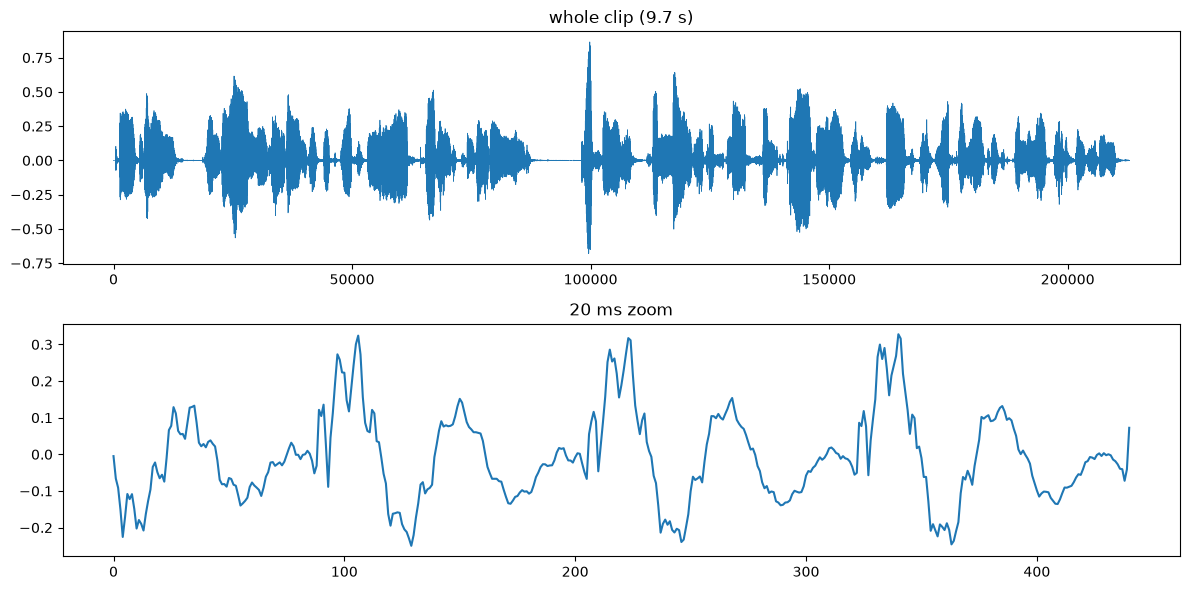

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6))
ax[0].plot(w, lw=0.5)
ax[0].set_title(f"whole clip ({len(w)/sr:.1f} s)")
ax[1].plot(w[20000:20000 + 441])   # 441 samples = 20 ms at 22.05 kHz
ax[1].set_title("20 ms zoom")
plt.tight_layout()

In [4]:
import torch

train = torch.load(DATA_DIR / "train_8000.pt")
print(train.dtype, train.shape, train.min(), train.max())

torch.uint8 torch.Size([633786164]) tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)


## Mel Spectrograms

In [5]:
from torchaudio.transforms import MelSpectrogram

waveform, sample_rate = w, sr

In [6]:
SR, N_FFT, HOP, N_MELS = 8000, 512, 128, 80    # single source of truth

transform = MelSpectrogram(
    sample_rate=SR, n_fft=N_FFT, hop_length=HOP,
    n_mels=N_MELS, f_min=0, f_max=SR // 2, power=1.0, center=True,
)

In [7]:
mel_specgram = transform(waveform)
mel_specgram.shape

torch.Size([80, 1664])

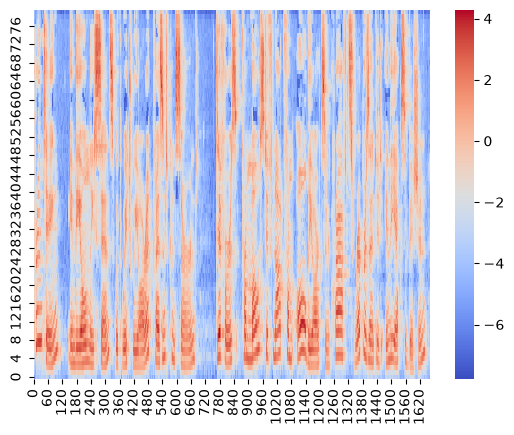

In [8]:
import seaborn as sns


sns.heatmap(torch.log(mel_specgram.clamp(min = 1e-5)),cmap='coolwarm')
ax = plt.gca()
ax.invert_yaxis()

In [9]:
d = torch.load("data/train_8000_mel.pt")
m = torch.cat([x.float() for x in d["mels"]], dim=1)
print(len(d["codes"]), m.shape, m.mean(dim=1).abs().max(), m.std(dim=1).mean())
# expect ~190 clips, (80, ~50k), ~0, ~1

FileNotFoundError: [Errno 2] No such file or directory: 'data/train_8000_mel.pt'

In [11]:
from torch.utils.data import DataLoader
from wavenet.data import MelChunks

d = torch.load(DATA_DIR / "train_8000_mel.pt")

T, rf = 4096, 1024
ds = MelChunks(d["codes"], d["mels"], T=T, rf=rf)

x, c, y = next(iter(DataLoader(ds, batch_size=8)))
print(x.shape, c.shape, y.shape, x.dtype, c.dtype)
# expect (8, 4096) (8, 80, 32) (8, 4096) int64 float32

assert (y[:, : rf - 1] == -1).all()
assert (y[:, rf - 1 : -1] == x[:, rf:]).all()     # y[t] == x[t+1] where unmasked
assert torch.isfinite(c).all()

# val: deterministic
val = torch.load(DATA_DIR / f"val_{SR}_mel.pt")
vds = MelChunks(val["codes"], val["mels"], T=T, rf=rf, random=False)
a, b = vds[0], vds[0]
assert all(torch.equal(p, q) for p, q in zip(a, b))

MelChunks: 12445 clips (0 dropped), 4,559,416 valid windows, 10,000 items
torch.Size([8, 4096]) torch.Size([8, 80, 32]) torch.Size([8, 4096]) torch.int64 torch.float32
MelChunks: 655 clips (0 dropped), 240,316 valid windows, 7,829 items
